
# CNN Transfer Baseline — DeepFakeDetector

**Goal:** Fine-tune a pretrained CNN to classify images as **Real** vs **AI-generated** (deepfakes).  
This notebook is a **beginner-friendly, end-to-end baseline** that you can run locally or in Colab.

**Backbones supported:** `EfficientNet-B0` (default) and `ResNet-50` (toggle below).  
**Metrics:** Accuracy, F1, AUROC.  
**Extras:** Optional saliency map for interpretability, model checkpointing, and clear instructions.

> ✅ This file is the deliverable requested by the issue: `notebooks/cnn_transfer_baseline.ipynb`.


In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 0. Setup

- You need Python 3.10+ recommended.
- If running the notebook locally, install dependencies with the cell below.
- If running in **Google Colab**, the cell will also work; GPU is recommended.

> Dataset (expected folder structure):
```
data/
  train/
    real/
    fake/
  val/
    real/
    fake/
```
- Each folder contains images (JPG/PNG). You may rename `fake` to `ai` if you like—just update the `CLASS_NAMES` below.


In [70]:
!apt-get update -qq
!apt-get install -y -qq unzip
!unzip -q -o /content/datasets.zip -d /content
!find /content/datasets -maxdepth 3 -type d -print

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
unzip:  cannot find or open /content/datasets.zip, /content/datasets.zip.zip or /content/datasets.zip.ZIP.
find: ‘/content/datasets’: No such file or directory


In [48]:

# If you are on Colab or a fresh environment, uncomment and run:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install scikit-learn matplotlib tqdm pillow captum


In [71]:
# =========================
# CELL 1: Imports + config
# =========================
import os, time, copy, math, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Make DEVICE a torch.device (not a string)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Beginner-friendly switches ----
USE_MODEL = "efficientnet_b0"
FREEZE_BACKBONE = True
UNFREEZE_EPOCH = 3              # set None to keep frozen
NUM_EPOCHS = 10

# You can crank this up later if it fits
BATCH_SIZE = 64

LR = 1e-3
WEIGHT_DECAY = 1e-4

# When using local /content data, 2-4 is good
# If you see stalls, set to 0
NUM_WORKERS = 2

IM_SIZE = 224

Using device: cuda


In [50]:
# =========================
# CELL 2: Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic can reduce speed but improves reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed set.")


Seed set.



## 1. Data Loading and Augmentations

- We use `ImageFolder` so the folder names define classes.
- Basic augmentations help generalization.


In [75]:
# ==========================================
# CELL: Combined training on OpenFake + DRAGON + wildfake_2k_split (train + test)
# - mounts Drive if needed
# - copies each dataset split from Drive -> /content once (speed)
# - builds ImageFolder datasets
# - remaps labels to enforce: 0=real, 1=fake (consistent)
# - concatenates train + test across all datasets
# ==========================================

from pathlib import Path
import shutil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------- Settings --------
IM_SIZE = int(globals().get("IM_SIZE", 224))
BATCH_SIZE = int(globals().get("BATCH_SIZE", 64))
NUM_WORKERS = int(globals().get("NUM_WORKERS", 2))
PIN_MEMORY = True

# -------- Ensure Drive mounted --------
if not Path("/content/drive").exists():
    from google.colab import drive
    drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/datasets")

DATASETS = {
    "OpenFake": DRIVE_ROOT / "OpenFake",
    "DRAGON": DRIVE_ROOT / "DRAGON",
    "wildfake_2k_split": DRIVE_ROOT / "wildfake_2k_split",
}

TRAIN_NAMES = ["train", "Train", "training"]
TEST_NAMES  = ["test", "Test", "val", "Val", "valid", "validation"]

def find_split(base: Path, split_names):
    for n in split_names:
        p = base / n
        if p.exists() and p.is_dir():
            return p
    for child in base.iterdir():
        if child.is_dir():
            for n in split_names:
                p = child / n
                if p.exists() and p.is_dir():
                    return p
    return None

# -------- Transforms --------
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_tfm = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    normalize,
])

test_tfm = transforms.Compose([
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    normalize,
])

globals()["train_tfm"] = train_tfm
globals()["val_tfm"] = test_tfm  # keep val_tfm name since training cell expects it

# -------- Label remap wrapper: enforce 0=real, 1=fake --------
class RemapLabels(Dataset):
    def __init__(self, base_ds, class_to_idx):
        self.base_ds = base_ds
        # base_ds returns labels in its own index space; map them to desired space
        # desired: real->0, fake->1
        if "real" not in class_to_idx or "fake" not in class_to_idx:
            raise RuntimeError(f"Expected 'real' and 'fake' classes, got {class_to_idx}")
        self.map = {
            class_to_idx["real"]: 0,
            class_to_idx["fake"]: 1
        }

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        x, y = self.base_ds[idx]
        return x, self.map[int(y)]

def wrap_imagefolder_with_remap(ds: datasets.ImageFolder, name: str):
    # ds.class_to_idx may be {'fake':0,'real':1} or {'real':0,'fake':1}
    wrapped = RemapLabels(ds, ds.class_to_idx)
    return wrapped

train_parts = []
val_parts = []  # test split goes here (your training loop uses val_loader)

for name, base_drive in DATASETS.items():
    if not base_drive.exists():
        raise FileNotFoundError(f"Missing dataset folder on Drive: {base_drive}")

    train_drive = find_split(base_drive, TRAIN_NAMES)
    test_drive  = find_split(base_drive, TEST_NAMES)

    print(f"\n{name} base:", base_drive)
    print(f"{name} train:", train_drive)
    print(f"{name} test :", test_drive)

    if train_drive is None or test_drive is None:
        print(f"{name}: could not find train/test. Listing one level under base:")
        for p in sorted(base_drive.iterdir()):
            if p.is_dir():
                print(" -", p)
        raise FileNotFoundError(f"{name}: train/test split folders not found under {base_drive}")

    local_root = Path("/content") / f"dataset_local_{name}"
    train_local = local_root / "train"
    test_local  = local_root / "test"

    if not train_local.exists() or not test_local.exists():
        print(f"{name}: copying to local disk for speed...")
        if local_root.exists():
            shutil.rmtree(local_root)
        local_root.mkdir(parents=True, exist_ok=True)
        shutil.copytree(train_drive, train_local)
        shutil.copytree(test_drive,  test_local)
        print(f"{name}: copy complete -> {local_root}")
    else:
        print(f"{name}: local copy exists -> {local_root}")

    ds_tr_raw = datasets.ImageFolder(str(train_local), transform=train_tfm)
    ds_te_raw = datasets.ImageFolder(str(test_local),  transform=test_tfm)

    print(f"{name}: raw classes={ds_tr_raw.classes} raw class_to_idx={ds_tr_raw.class_to_idx}")

    # Wrap to enforce: 0=real, 1=fake no matter what ImageFolder picked
    ds_tr = wrap_imagefolder_with_remap(ds_tr_raw, name)
    ds_te = wrap_imagefolder_with_remap(ds_te_raw, name)

    print(f"{name}: train={len(ds_tr_raw)} test={len(ds_te_raw)} (labels remapped to 0=real,1=fake)")

    train_parts.append(ds_tr)
    val_parts.append(ds_te)

# -------- Combined datasets --------
train_ds = ConcatDataset(train_parts)
val_ds   = ConcatDataset(val_parts)

globals()["train_ds"] = train_ds
globals()["val_ds"] = val_ds

# -------- Loaders --------
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

globals()["train_loader"] = train_loader
globals()["val_loader"] = val_loader

print("\n✅ Combined dataset ready (consistent labels: 0=real, 1=fake)")
print("batch_size:", BATCH_SIZE, "num_workers:", NUM_WORKERS)
print("train size:", len(train_ds), "test-as-val size:", len(val_ds))
print("batches/epoch:", len(train_loader))

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), "label values:", sorted(set(yb.tolist())))


OpenFake base: /content/drive/MyDrive/datasets/OpenFake
OpenFake train: /content/drive/MyDrive/datasets/OpenFake/train
OpenFake test : /content/drive/MyDrive/datasets/OpenFake/test
OpenFake: local copy exists -> /content/dataset_local_OpenFake
OpenFake: raw classes=['fake', 'real'] raw class_to_idx={'fake': 0, 'real': 1}
OpenFake: train=8987 test=1000 (labels remapped to 0=real,1=fake)

DRAGON base: /content/drive/MyDrive/datasets/DRAGON
DRAGON train: /content/drive/MyDrive/datasets/DRAGON/train
DRAGON test : /content/drive/MyDrive/datasets/DRAGON/test
DRAGON: copying to local disk for speed...
DRAGON: copy complete -> /content/dataset_local_DRAGON
DRAGON: raw classes=['fake', 'real'] raw class_to_idx={'fake': 0, 'real': 1}
DRAGON: train=959 test=188 (labels remapped to 0=real,1=fake)

wildfake_2k_split base: /content/drive/MyDrive/datasets/wildfake_2k_split
wildfake_2k_split train: /content/drive/MyDrive/datasets/wildfake_2k_split/train
wildfake_2k_split test : /content/drive/MyDrive

In [52]:
# =========================
# ONE-CELL: Colab manual-gen dataset setup (HF -> /content/manual_gen_images)
# Safer: uses Colab Secrets env var HF_TOKEN, no interactive login()
# =========================

!pip -q install -U huggingface_hub datasets

from pathlib import Path
import os
import shutil
from huggingface_hub import snapshot_download
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError

DATASET_REPO = "DeepFakeDetector/manual-gen-images"

# 1) Read token safely from environment (Colab Secrets)
from google.colab import userdata

token = (userdata.get("HF_TOKEN") or "").strip()
if not token:
    raise RuntimeError("HF_TOKEN secret not found. In Colab Secrets, name must be exactly HF_TOKEN and Notebook access must be enabled.")

# optional: export to env so the rest of your code can use os.environ["HF_TOKEN"]
os.environ["HF_TOKEN"] = token
# 2) Download dataset snapshot (raw repo files)
try:
    local_snapshot = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            token=token,
        )
    )
except RepositoryNotFoundError as e:
    raise RuntimeError(
        f"Repo not found: {DATASET_REPO}. Check spelling and that it is a dataset repo."
    ) from e
except HfHubHTTPError as e:
    # Common: 401 if private/gated or no access
    raise RuntimeError(
        f"HF download failed. If you see 401, you are not authenticated or you do not have access "
        f"to {DATASET_REPO}. Make sure your token is valid and you have permission."
    ) from e

print("Downloaded HF dataset snapshot to:", local_snapshot)

# 3) Build a clean output directory
OUT_ROOT = Path("/content/manual_gen_images")
OUT_IMAGES = OUT_ROOT / "images"
OUT_IMAGES.mkdir(parents=True, exist_ok=True)

# 4) Copy images into /content/manual_gen_images/images/<generator>/
IMG_EXTS = {".png", ".jpg", ".jpeg", ".webp"}

def norm(s: str) -> str:
    return s.lower().replace(" ", "").replace("-", "_")

def guess_gen(path: Path) -> str:
    parts = [norm(p) for p in path.parts]
    if "nanobanana" in parts or "nano_banana" in parts:
        return "nanobanana"
    if "dalle" in parts or "dall_e" in parts or "dall-e" in parts:
        return "dalle"
    if "bing" in parts:
        return "bing"
    parent = norm(path.parent.name)
    if "nano" in parent:
        return "nanobanana"
    if "dall" in parent:
        return "dalle"
    if "bing" in parent:
        return "bing"
    return "unknown"

copied = 0
per_gen = {}

for img_path in local_snapshot.rglob("*"):
    if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
        gen = guess_gen(img_path)
        dest_dir = OUT_IMAGES / gen
        dest_dir.mkdir(parents=True, exist_ok=True)

        dest = dest_dir / img_path.name
        if dest.exists():
            dest = dest_dir / f"{img_path.stem}_{copied}{img_path.suffix}"

        shutil.copy2(img_path, dest)
        copied += 1
        per_gen[gen] = per_gen.get(gen, 0) + 1

print("\n✅ Manual-gen images ready at:", OUT_IMAGES)
print("Counts by generator:", dict(sorted(per_gen.items(), key=lambda x: x[0])))
for g in sorted(per_gen):
    print(" -", OUT_IMAGES / g)

Fetching 331 files:   0%|          | 0/331 [00:00<?, ?it/s]

Downloaded HF dataset snapshot to: /root/.cache/huggingface/hub/datasets--DeepFakeDetector--manual-gen-images/snapshots/7d96c89dacfbba469ccd9bddbd1a486cff72b3a1

✅ Manual-gen images ready at: /content/manual_gen_images/images
Counts by generator: {'bing': 27, 'dalle': 100, 'nanobanana': 100}
 - /content/manual_gen_images/images/bing
 - /content/manual_gen_images/images/dalle
 - /content/manual_gen_images/images/nanobanana



## 2. Build the Model (Transfer Learning)

Pick a pretrained backbone and replace the classification head with a 2‑class head.


In [81]:
# =========================
# CELL 4: Model, loss, optimizer (safe: never-empty optimizer)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim

# Ensure DEVICE is torch.device
if "DEVICE" in globals() and isinstance(DEVICE, str):
    DEVICE = torch.device(DEVICE)
elif "DEVICE" not in globals() or not isinstance(DEVICE, torch.device):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(USE_MODEL, num_classes=2, freeze_backbone=FREEZE_BACKBONE).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def _make_optimizer_for_trainable_params(m, lr, wd):
    trainable_params = [p for p in m.parameters() if p.requires_grad]
    print("trainable param tensors:", len(trainable_params))
    if len(trainable_params) == 0:
        raise RuntimeError(
            "No trainable parameters. Your model is fully frozen. "
            "Set FREEZE_BACKBONE=False, or ensure the classifier head is unfrozen."
        )
    return optim.AdamW(trainable_params, lr=lr, weight_decay=wd)

optimizer = _make_optimizer_for_trainable_params(model, LR, WEIGHT_DECAY)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model: {USE_MODEL} | Trainable params: {trainable:,} / {total:,} | device: {next(model.parameters()).device}")

trainable param tensors: 2
Model: efficientnet_b0 | Trainable params: 2,562 / 4,010,110 | device: cuda:0



## 3. Training & Validation Loop

- Trains with the head (and optionally unfreezes the backbone later).
- Tracks Accuracy, F1, and AUROC.
- Saves the **best** model checkpoint by AUROC.


In [82]:
# =========================
# CELL 3: Train loop with OneCycleLR + warmup + early stopping on val AUROC
# Fixes:
#  - Drive run dirs
#  - best_{USE_MODEL}.pt naming
#  - optimizer rebuilt from trainable params after unfreeze
#  - AMP guard so GradScaler never hits the "No inf checks" assertion
# =========================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import math, time
from pathlib import Path
import numpy as np
import torch
import torch.optim as optim

# --------- Drive run directory setup ----------
DRIVE_BASE = Path("/content/drive/MyDrive/DeepFakeDetector_runs")
RUN_NAME = time.strftime("cnn_transfer_%Y%m%d_%H%M%S")
DRIVE_RUN_DIR = DRIVE_BASE / RUN_NAME
DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CKPT_DIR = DRIVE_RUN_DIR / "checkpoints"
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_ARTIFACTS_DIR = DRIVE_RUN_DIR / "artifacts"
DRIVE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Drive run dir:", DRIVE_RUN_DIR)
# --------------------------------------------

# Local artifacts (still useful for downstream cells)
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

best_path = DRIVE_CKPT_DIR / f"best_{USE_MODEL}.pt"

FAKE_IDX = 1  # fixed convention: 0 real, 1 fake

HEARTBEAT_EVERY = 50
SMI_EVERY = 200  # set 0 to disable

# Ensure DEVICE is torch.device
if "DEVICE" in globals() and isinstance(DEVICE, str):
    DEVICE = torch.device(DEVICE)
elif "DEVICE" not in globals() or not isinstance(DEVICE, torch.device):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

use_amp = (DEVICE.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def _rebuild_optimizer_trainable(lr):
    global optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    print("trainable param tensors (optimizer rebuild):", len(trainable_params))
    if len(trainable_params) == 0:
        raise RuntimeError("Optimizer rebuild found 0 trainable params. Model is still frozen.")
    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    probs_all, y_all = [], []
    running_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.inference_mode()
    with ctx:
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    logits = model(imgs)
                    loss = criterion(logits, labels)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)

            if is_train:
                if use_amp:
                    scaler.scale(loss).backward()

                    has_any_grad = any(
                        (p.grad is not None)
                        for group in optimizer.param_groups
                        for p in group["params"]
                    )
                    if not has_any_grad:
                        raise RuntimeError(
                            "No gradients found during AMP step. "
                            "Your optimizer likely has 0 trainable params or model is fully frozen."
                        )

                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()

                    has_any_grad = any(
                        (p.grad is not None)
                        for group in optimizer.param_groups
                        for p in group["params"]
                    )
                    if not has_any_grad:
                        raise RuntimeError(
                            "No gradients found. Your optimizer likely has 0 trainable params or model is fully frozen."
                        )

                    optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            probs_fake = torch.softmax(logits.detach(), dim=1)[:, FAKE_IDX]
            probs_all.append(probs_fake.float().cpu().numpy())
            y_all.append(labels.detach().cpu().numpy())

    y_prob = np.concatenate(probs_all) if probs_all else np.array([])
    y_true = np.concatenate(y_all) if y_all else np.array([])

    y_pred = (y_prob >= 0.5).astype(int) if y_prob.size else np.array([])
    epoch_loss = running_loss / max(1, len(loader.dataset))

    acc = accuracy_score(y_true, y_pred) if y_true.size else float("nan")
    f1  = f1_score(y_true, y_pred, zero_division=0) if y_true.size else float("nan")
    try:
        auroc = roc_auc_score(y_true, y_prob) if y_true.size else float("nan")
    except ValueError:
        auroc = float("nan")

    return epoch_loss, acc, f1, auroc

steps_per_epoch = len(train_loader)
WARMUP_EPOCHS = 1
MAX_LR = LR

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=(WARMUP_EPOCHS / max(1, NUM_EPOCHS)),
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0
)

best_auroc = -1.0
history = {"train": [], "val": []}
PATIENCE = 3
pat = 0

print(f"Training {USE_MODEL} for up to {NUM_EPOCHS} epochs | OneCycleLR warmup={WARMUP_EPOCHS} | patience={PATIENCE}")
print("cuda available:", torch.cuda.is_available())
print("model device:", next(model.parameters()).device)
print("batches per epoch:", len(train_loader))

for epoch in range(1, NUM_EPOCHS + 1):
    if UNFREEZE_EPOCH is not None and epoch == UNFREEZE_EPOCH:
        print(f"Unfreezing backbone at epoch {epoch} and reinitializing optimizer/scheduler...")

        backbone = None
        for attr in ["features", "backbone", "encoder"]:
            if hasattr(model, attr):
                backbone = getattr(model, attr)
                break

        if backbone is not None:
            for p in backbone.parameters():
                p.requires_grad = True
        else:
            for p in model.parameters():
                p.requires_grad = True

        _rebuild_optimizer_trainable(lr=LR/10)

        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=LR/10,
            epochs=(NUM_EPOCHS - epoch + 1),
            steps_per_epoch=steps_per_epoch,
            pct_start=0.3,
            anneal_strategy="cos",
            div_factor=10.0,
            final_div_factor=100.0
        )

    t0 = time.time()
    model.train(True)
    running_loss = 0.0
    probs_all, y_all = [], []

    for step, (imgs, labels) in enumerate(train_loader, start=1):
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if epoch == 1 and step == 1:
            print("first batch:", tuple(imgs.shape), imgs.device, imgs.dtype)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(imgs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            has_any_grad = any(
                (p.grad is not None)
                for group in optimizer.param_groups
                for p in group["params"]
            )
            if not has_any_grad:
                raise RuntimeError(
                    "No gradients found during AMP step. "
                    "Your optimizer likely has 0 trainable params or model is fully frozen."
                )

            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()

            has_any_grad = any(
                (p.grad is not None)
                for group in optimizer.param_groups
                for p in group["params"]
            )
            if not has_any_grad:
                raise RuntimeError(
                    "No gradients found. Your optimizer likely has 0 trainable params or model is fully frozen."
                )

            optimizer.step()

        scheduler.step()

        if HEARTBEAT_EVERY and step % HEARTBEAT_EVERY == 0:
            print(f"epoch {epoch} step {step}/{len(train_loader)} loss {loss.item():.4f}")

        if SMI_EVERY and DEVICE.type == "cuda" and step % SMI_EVERY == 0:
            import subprocess
            out = subprocess.check_output([
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total",
                "--format=csv,noheader,nounits"
            ]).decode().strip()
            print("gpu util %, mem used/total MiB:", out)

        running_loss += loss.item() * imgs.size(0)
        probs_fake = torch.softmax(logits.detach(), dim=1)[:, FAKE_IDX]
        probs_all.append(probs_fake.float().cpu().numpy())
        y_all.append(labels.detach().cpu().numpy())

    tr_loss = running_loss / max(1, len(train_loader.dataset))
    y_prob_tr = np.concatenate(probs_all) if probs_all else np.array([])
    y_true_tr = np.concatenate(y_all) if y_all else np.array([])
    tr_pred = (y_prob_tr >= 0.5).astype(int) if y_prob_tr.size else np.array([])

    tr_acc = accuracy_score(y_true_tr, tr_pred) if y_true_tr.size else float("nan")
    tr_f1  = f1_score(y_true_tr, tr_pred, zero_division=0) if y_true_tr.size else float("nan")
    try:
        tr_auc = roc_auc_score(y_true_tr, y_prob_tr) if y_true_tr.size else float("nan")
    except ValueError:
        tr_auc = float("nan")

    va_loss, va_acc, va_f1, va_auc = run_epoch(model, val_loader, optimizer=None)

    dt = time.time() - t0
    history["train"].append((tr_loss, tr_acc, tr_f1, tr_auc))
    history["val"].append((va_loss, va_acc, va_f1, va_auc))

    print(f"Epoch {epoch:02d} | {dt:.1f}s "
          f"| train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} auroc {tr_auc:.3f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f} auroc {va_auc:.3f}")

    if not math.isnan(va_auc) and va_auc > best_auroc:
        best_auroc = va_auc
        pat = 0

        torch.save({
            "model_state": model.state_dict(),
            "arch": USE_MODEL,
            "im_size": IM_SIZE,
            "label_map": {"0": "real", "1": "fake"},
            "threshold_default": 0.5,
            "best_val_auroc": float(best_auroc)
        }, best_path)

        # also mirror locally for convenience
        local_best = ARTIFACTS_DIR / f"best_{USE_MODEL}.pt"
        try:
            import shutil
            shutil.copy2(best_path, local_best)
        except Exception as e:
            print("Warning: could not copy best ckpt to local artifacts:", e)

        print(f"Saved new best checkpoint (val AUROC={best_auroc:.3f}) -> {best_path}")
    else:
        pat += 1
        print(f"No AUROC improvement. Patience {pat}/{PATIENCE}")
        if pat >= PATIENCE:
            print("Early stopping triggered.")
            break

Drive run dir: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119
Training efficientnet_b0 for up to 10 epochs | OneCycleLR warmup=1 | patience=3
cuda available: True
model device: cuda:0
batches per epoch: 181
first batch: (64, 3, 224, 224) cuda:0 torch.float32
epoch 1 step 50/181 loss 0.6404
epoch 1 step 100/181 loss 0.6159
epoch 1 step 150/181 loss 0.6326
Epoch 01 | 118.8s | train loss 0.6351 acc 0.652 f1 0.674 auroc 0.713 | val loss 0.5623 acc 0.758 f1 0.788 auroc 0.822
Saved new best checkpoint (val AUROC=0.822) -> /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/checkpoints/best_efficientnet_b0.pt
epoch 2 step 50/181 loss 0.5841
epoch 2 step 100/181 loss 0.5230
epoch 2 step 150/181 loss 0.5782
Epoch 02 | 104.6s | train loss 0.5572 acc 0.745 f1 0.765 auroc 0.821 | val loss 0.5368 acc 0.779 f1 0.808 auroc 0.844
Saved new best checkpoint (val AUROC=0.844) -> /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/chec

In [55]:
!nvidia-smi

Sat Feb 21 13:16:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             33W /   70W |    3563MiB /  15360MiB |     48%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


## 4. Curves


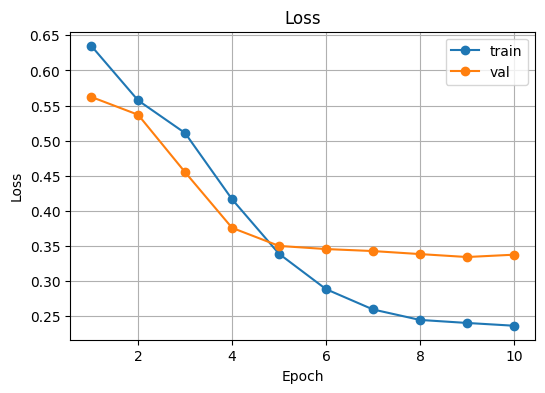

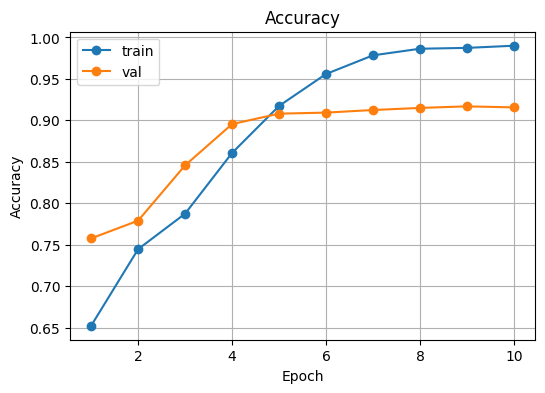

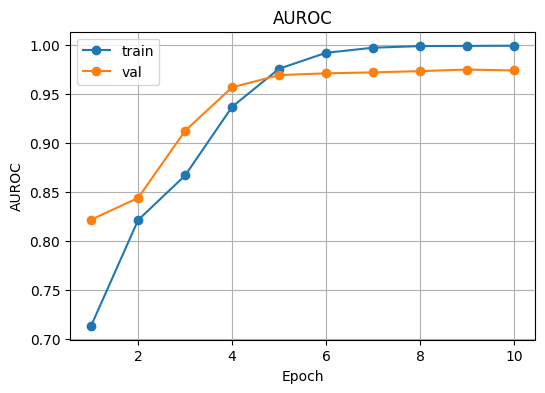

In [83]:
# =========================
# CELL 4: Curves (train vs val)
# =========================

import matplotlib.pyplot as plt

tr_acc = [x[1] for x in history["train"]]
va_acc = [x[1] for x in history["val"]]
tr_loss = [x[0] for x in history["train"]]
va_loss = [x[0] for x in history["val"]]
tr_auc = [x[3] for x in history["train"]]
va_auc = [x[3] for x in history["val"]]
epochs = range(1, len(tr_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_loss, marker="o", label="train")
plt.plot(list(epochs), va_loss, marker="o", label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_acc, marker="o", label="train")
plt.plot(list(epochs), va_acc, marker="o", label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(epochs), tr_auc, marker="o", label="train")
plt.plot(list(epochs), va_auc, marker="o", label="val")
plt.title("AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.legend()
plt.grid(True)
plt.show()



## 5. Optional: Simple Saliency Map (Captum)

This helps **explain** which pixels most influence the prediction.  
Run after training. Provide a path to a single image.


In [84]:
# =========================
# CELL 7: Load best checkpoint (local first, then Drive fallback)
# Works with per-run Drive folders and best_{USE_MODEL}.pt naming
# =========================
from pathlib import Path
import torch
import shutil

ARTIFACTS_DIR = Path(globals().get("ARTIFACTS_DIR", "artifacts"))
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def _find_drive_ckpt():
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        return None

    base = drive_root / "DeepFakeDetector_runs"
    if not base.exists():
        return None

    best_name = f"best_{USE_MODEL}.pt"

    # 1) If current session has DRIVE_CKPT_DIR from training, use it directly
    if "DRIVE_CKPT_DIR" in globals() and globals().get("DRIVE_CKPT_DIR") is not None:
        p = Path(globals()["DRIVE_CKPT_DIR"]) / best_name
        if p.exists():
            return p

    # 2) Otherwise, pick newest run checkpoint
    candidates = sorted(
        base.glob("*/checkpoints/" + best_name),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return candidates[0] if candidates else None

def load_best_checkpoint():
    best_name = f"best_{USE_MODEL}.pt"
    local_ckpt = ARTIFACTS_DIR / best_name
    drive_ckpt = _find_drive_ckpt()

    if local_ckpt.exists():
        ckpt_path = local_ckpt
    elif drive_ckpt is not None and drive_ckpt.exists():
        shutil.copy2(drive_ckpt, local_ckpt)
        ckpt_path = local_ckpt
    else:
        raise FileNotFoundError(
            f"No checkpoint found at {local_ckpt}"
            + (f" or {drive_ckpt}" if drive_ckpt is not None else "")
            + ". Train first (the cell that saves best checkpoints)."
        )

    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)

    model_name = ckpt.get("model_name") or ckpt.get("arch") or ckpt.get("model") or USE_MODEL
    m = build_model(model_name, num_classes=2, freeze_backbone=False).to(DEVICE)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    return m, ckpt, ckpt_path

model, ckpt, ckpt_path = load_best_checkpoint()
print("Loaded:", ckpt.get("model_name") or ckpt.get("arch") or USE_MODEL)
print("Checkpoint path:", ckpt_path)
print("Label map:", ckpt.get("label_map"))

Loaded: efficientnet_b0
Checkpoint path: artifacts/best_efficientnet_b0.pt
Label map: {'0': 'real', '1': 'fake'}


In [85]:
# =========================
# MANUAL TESTS - CELL B (prints confusion matrix too)
# - prints numeric CM + saves PNG + saves CSV
# =========================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

FAKE_IDX = int(globals().get("FAKE_IDX", 1))

# Pick validation transform
val_transform = globals().get("val_tfm") or globals().get("val_tfms")
if val_transform is None:
    raise NameError("No validation transform found. Expected val_tfm or val_tfms.")

# Manual images root
MANUAL_IMAGES_ROOT = Path(globals().get("MANUAL_IMAGES_ROOT", "/content/manual_gen_images/images"))
if not MANUAL_IMAGES_ROOT.exists():
    raise FileNotFoundError(f"Manual images root not found: {MANUAL_IMAGES_ROOT}")

def _is_image(p: Path) -> bool:
    return p.suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]

class ManualGenFakeDataset(Dataset):
    def __init__(self, img_paths, transform, fake_label=1):
        self.img_paths = list(img_paths)
        self.transform = transform
        self.fake_label = int(fake_label)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        im = Image.open(p).convert("RGB")
        x = self.transform(im)
        y = self.fake_label
        return x, y, str(p)

@torch.inference_mode()
def _collect_probs_and_paths(model, loader, device, fake_idx=1):
    model.eval()
    probs, ys, paths = [], [], []
    for xb, yb, pb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        prob_fake = torch.softmax(logits, dim=1)[:, int(fake_idx)].detach().cpu().numpy()
        probs.append(prob_fake)
        ys.append(np.asarray(yb))
        paths.extend(list(pb))
    return np.concatenate(probs), np.concatenate(ys), paths

def _save_confusion_matrix_png(cm, out_path: Path, title: str):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Real", "Fake"])
    plt.yticks([0, 1], ["Real", "Fake"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=200)
    plt.close()

def _pretty_print_cm(cm: np.ndarray):
    # cm layout with labels=[0,1] is:
    # [[tn, fp],
    #  [fn, tp]]
    tn, fp, fn, tp = cm.ravel()
    print("Confusion matrix (rows=actual, cols=pred):")
    print("            pred_real  pred_fake")
    print(f"actual_real     {tn:6d}    {fp:6d}")
    print(f"actual_fake     {fn:6d}    {tp:6d}")
    print(f"(tn={tn}, fp={fp}, fn={fn}, tp={tp})")

def test_manual_deepfakes(generator_name: str,
                          threshold: float = 0.5,
                          batch_size: int = 64,
                          num_workers: int = 2):
    gen_dir = MANUAL_IMAGES_ROOT / generator_name
    if not gen_dir.exists():
        available = [p.name for p in MANUAL_IMAGES_ROOT.iterdir() if p.is_dir()]
        raise FileNotFoundError(
            f"Missing generator folder: {gen_dir}\n"
            f"Available generators under {MANUAL_IMAGES_ROOT}: {available}"
        )

    img_paths = sorted([p for p in gen_dir.rglob("*") if p.is_file() and _is_image(p)])
    if len(img_paths) == 0:
        raise RuntimeError(f"No images found under: {gen_dir}")

    ds = ManualGenFakeDataset(img_paths, transform=val_transform, fake_label=1)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(getattr(DEVICE, "type", "") == "cuda"),
        persistent_workers=(num_workers > 0),
    )

    print(f"\n[{generator_name}] n={len(ds)} batch_size={batch_size} num_workers={num_workers}")
    y_prob, y_true, paths = _collect_probs_and_paths(model, loader, device=DEVICE, fake_idx=FAKE_IDX)

    thr = float(threshold)
    y_pred = (y_prob >= thr).astype(int)

    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    _pretty_print_cm(cm)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else None
    specificity = tn / (tn + fp) if (tn + fp) > 0 else None

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall on fake (sensitivity): {sensitivity if sensitivity is not None else 'n/a'}")
    print(f"Specificity: {specificity if specificity is not None else 'n/a'}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=["real", "fake"],
        zero_division=0
    ))

    out_dir = Path(ARTIFACTS_DIR) / "manual_gen" / generator_name
    out_dir.mkdir(parents=True, exist_ok=True)

    pred_csv = out_dir / "predictions.csv"
    df = pd.DataFrame({
        "path": paths,
        "prob_fake": y_prob,
        "y_true": y_true,
        "y_pred": y_pred,
        "threshold": thr,
        "generator": generator_name,
    })
    df.to_csv(pred_csv, index=False)
    print("Saved predictions CSV:", pred_csv)

    cm_png = out_dir / "confusion_matrix.png"
    _save_confusion_matrix_png(cm, cm_png, title=f"{generator_name} (thr={thr})")
    print("Saved confusion matrix PNG:", cm_png)

    if "DRIVE_ARTIFACTS_DIR" in globals() and globals()["DRIVE_ARTIFACTS_DIR"] is not None:
        import shutil
        drive_out = Path(globals()["DRIVE_ARTIFACTS_DIR"]) / "manual_gen" / generator_name
        drive_out.parent.mkdir(parents=True, exist_ok=True)
        if drive_out.exists():
            shutil.rmtree(drive_out)
        shutil.copytree(out_dir, drive_out)
        print("Backed up to Drive:", drive_out)

    return {
        "generator": generator_name,
        "n": int(len(ds)),
        "threshold": thr,
        "acc": float(acc),
        "sensitivity": None if sensitivity is None else float(sensitivity),
        "specificity": None if specificity is None else float(specificity),
        "cm": cm,
        "pred_csv": str(pred_csv),
        "cm_png": str(cm_png),
    }

# Run tests
res_nanobanana = test_manual_deepfakes("nanobanana", threshold=0.5, batch_size=64, num_workers=2)
res_dalle = test_manual_deepfakes("dalle", threshold=0.5, batch_size=64, num_workers=2)
res_bing = test_manual_deepfakes("bing", threshold=0.5, batch_size=64, num_workers=2)


[nanobanana] n=200 batch_size=64 num_workers=2
Confusion matrix (rows=actual, cols=pred):
            pred_real  pred_fake
actual_real          0         0
actual_fake          4       196
(tn=0, fp=0, fn=4, tp=196)
Accuracy: 0.9800
Recall on fake (sensitivity): 0.98
Specificity: n/a

Classification Report:

              precision    recall  f1-score   support

        real       0.00      0.00      0.00         0
        fake       1.00      0.98      0.99       200

    accuracy                           0.98       200
   macro avg       0.50      0.49      0.49       200
weighted avg       1.00      0.98      0.99       200

Saved predictions CSV: artifacts/manual_gen/nanobanana/predictions.csv
Saved confusion matrix PNG: artifacts/manual_gen/nanobanana/confusion_matrix.png
Backed up to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/artifacts/manual_gen/nanobanana

[dalle] n=200 batch_size=64 num_workers=2
Confusion matrix (rows=actual, cols=pred)


## 6. Inference Helper


In [86]:
# =========================
# CELL 8: Cross-dataset eval for Issue #38
# - pick threshold on OpenFake val (max F1)
# - apply same threshold to WildFake and DRAGON
# - save metrics CSV, confusion matrices, ROC curves
# - backup everything to Drive
# =========================
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc

CROSS_DIR = ARTIFACTS_DIR / "cross_dataset"
CROSS_DIR.mkdir(parents=True, exist_ok=True)

@torch.inference_mode()
def collect_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y in loader:
        imgs = imgs.to(DEVICE, non_blocking=False)
        logits = model(imgs)
        probs_fake = torch.softmax(logits, dim=1)[:, FAKE_IDX]
        probs_all.append(probs_fake.detach().cpu().numpy())
        y_all.append(y.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)

def pick_threshold_on_val(y_prob, y_true):
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_score = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return float(best_t), float(best_score)

def eval_with_threshold(y_prob, y_true, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return float(acc), float(f1), float(auroc), cm

def save_confusion_matrix(cm, title, out_path):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["real(0)", "fake(1)"])
    plt.yticks([0, 1], ["real(0)", "fake(1)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_roc_curve(y_prob, y_true, title, out_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

# Dataset paths
DATASETS_ROOT = Path("/content/drive/MyDrive/datasets")
OPENFAKE_VAL_DIR = Path(val_dir)
WILDFAKE_VAL_DIR = DATASETS_ROOT / "wildfake_2k_split" / "test"
DRAGON_VAL_DIR   = DATASETS_ROOT / "DRAGON" / "test"

for d in [WILDFAKE_VAL_DIR, DRAGON_VAL_DIR]:
    assert d.exists(), f"Missing folder: {d}"
    assert (d / "real").exists() and (d / "fake").exists(), f"{d} must contain real/ and fake/"

# Choose threshold on OpenFake val
a_val_ds = imagefolder_fixed_labels(OPENFAKE_VAL_DIR, transform=val_tfms)
a_val_loader = DataLoader(a_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

y_prob_A, y_raw_A = collect_probs(model, a_val_loader)
y_true_A = (y_raw_A == FAKE_IDX).astype(int)

best_t, best_f1 = pick_threshold_on_val(y_prob_A, y_true_A)
print(f"Chosen threshold on OpenFake val (max F1): t={best_t:.3f} (F1={best_f1:.3f})")

datasets_to_eval = [
    ("A(OpenFake)", OPENFAKE_VAL_DIR),
    ("B(wildfake_2k_split)", WILDFAKE_VAL_DIR),
    ("C(DRAGON)", DRAGON_VAL_DIR),
]

rows = []
for tag, split_path in datasets_to_eval:
    ds = imagefolder_fixed_labels(split_path, transform=val_tfms)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=False)

    y_prob, y_raw = collect_probs(model, loader)
    y_true = (y_raw == FAKE_IDX).astype(int)

    acc, f1, auroc, cm = eval_with_threshold(y_prob, y_true, threshold=best_t)

    rows.append({
        "dataset": tag,
        "n": len(ds),
        "threshold": best_t,
        "acc": acc,
        "f1": f1,
        "auroc": None if np.isnan(auroc) else auroc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    cm_path = CROSS_DIR / f"{tag}_confusion_matrix.png"
    roc_path = CROSS_DIR / f"{tag}_roc.png"
    save_confusion_matrix(cm, f"{tag} Confusion Matrix (t={best_t:.3f})", cm_path)
    save_roc_curve(y_prob, y_true, f"{tag} ROC Curve", roc_path)

metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_csv = CROSS_DIR / "cross_dataset_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

note_path = CROSS_DIR / "threshold_note.txt"
note_path.write_text(
    f"Threshold chosen on OpenFake validation by maximizing F1: t={best_t:.3f} (F1={best_f1:.3f}).\n"
    "Same threshold applied unchanged to wildfake_2k_split and DRAGON.\n"
    "Label mapping enforced as 0=real and 1=fake.\n"
)

print("Saved:", metrics_csv)
print("Saved:", note_path)
print("Saved plots in:", CROSS_DIR)

# # Backup whole cross_dataset folder to Drive
# DRIVE_CROSS_DIR = DRIVE_ARTIFACTS_DIR / "cross_dataset"
# if DRIVE_CROSS_DIR.exists():
#     shutil.rmtree(DRIVE_CROSS_DIR)
# shutil.copytree(CROSS_DIR, DRIVE_CROSS_DIR)
# print("Backed up cross-dataset artifacts to Drive:", DRIVE_CROSS_DIR)


Chosen threshold on OpenFake val (max F1): t=0.538 (F1=0.884)


,dataset,n,threshold,acc,f1,auroc,tn,fp,fn,tp
0,A(OpenFake),1000,0.538,0.879,0.883542,0.947306,420,58,63,459
1,B(wildfake_2k_split),400,0.538,0.995,0.994975,0.999625,200,0,2,198
2,C(DRAGON),188,0.538,1.000,1.000000,1.000000,5,0,0,183


Saved: artifacts/cross_dataset/cross_dataset_metrics.csv
Saved: artifacts/cross_dataset/threshold_note.txt
Saved plots in: artifacts/cross_dataset



## 7. Record Results (Fill After Training)

- **Backbone:** EfficientNet-B0 or ResNet-50  
- **Freeze > Unfreeze epoch:** e.g., 1–2 epochs frozen, unfreeze at 3  
- **Val Accuracy:** …  
- **Val F1:** …  
- **Val AUROC:** …  
- **Observations:** … (e.g., overfitting signs, which backbone worked better, any class imbalance tweaks)

> Tip: If your dataset is imbalanced, consider using `WeightedRandomSampler` or class weights in `CrossEntropyLoss`.


In [87]:
# =========================
# CELL 9: Export artifacts for Issue #42 (and back up to Drive)
# Exports:
# - model.pth
# - config.json (includes threshold)
# - preprocess.json
# - label_map.json
# - README.md
# =========================
import os, json
from datetime import datetime

EXPORT_DIR = Path("export/cnn-transfer")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save weights (state_dict only)
torch.save(model.state_dict(), EXPORT_DIR / "model.pth")

preprocess = {
    "input_size": [IM_SIZE, IM_SIZE],
    "resize": {"enabled": True, "size": [IM_SIZE, IM_SIZE]},
    "center_crop": {"enabled": False},
    "normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    "notes": "Resize to IM_SIZE x IM_SIZE then normalize with ImageNet mean/std."
}

label_map = {"0": "real", "1": "fake"}

config = {
    "name": "cnn-transfer",
    "framework": "pytorch",
    "arch": USE_MODEL,
    "num_classes": 2,
    "threshold": float(best_t) if "best_t" in globals() else 0.50,
    "labels": label_map,
    "exported_at_utc": datetime.utcnow().isoformat() + "Z",
    "notes": "CNN transfer baseline for deepfake detection. prob_fake = softmax(logits)[fake]."
}

readme = f"""---
license: apache-2.0
tags:
  - image-classification
  - deepfake-detection
  - pytorch
---

# CNN Transfer (DeepFakeDetector)

Binary image classifier for deepfake or AI-generated image detection.

## Label convention (fixed)
- 0 = real
- 1 = fake

## Preprocessing
- Resize to {IM_SIZE}x{IM_SIZE}
- Normalize with ImageNet mean/std

## Output
- prob_fake in [0, 1] computed as softmax(logits)[fake]
- decision threshold: {config["threshold"]:.3f}
"""

with open(EXPORT_DIR / "preprocess.json", "w") as f:
    json.dump(preprocess, f, indent=2)
with open(EXPORT_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
with open(EXPORT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
with open(EXPORT_DIR / "README.md", "w") as f:
    f.write(readme)

print("Exported files:", sorted([p.name for p in EXPORT_DIR.iterdir()]))

# Backup export folder to Drive
DRIVE_EXPORT_DIR = DRIVE_RUN_DIR / "export" / "cnn-transfer"
if DRIVE_EXPORT_DIR.exists():
    shutil.rmtree(DRIVE_EXPORT_DIR)
shutil.copytree(EXPORT_DIR, DRIVE_EXPORT_DIR)
print("Backed up export folder to Drive:", DRIVE_EXPORT_DIR)


Exported files: ['README.md', 'config.json', 'label_map.json', 'model.pth', 'preprocess.json']
Backed up export folder to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/export/cnn-transfer


/tmp/ipython-input-105710457.py:36: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "exported_at_utc": datetime.utcnow().isoformat() + "Z",



## 8. (Optional) Write a `requirements.txt`

Run this cell once to generate a minimal `requirements.txt` alongside artifacts.


In [88]:
# =========================
# CELL 10: Install Hugging Face hub client (safe to run)
# =========================
%pip -q install huggingface_hub


In [89]:
import os, getpass

os.environ["HF_TOKEN_WRITE"] = getpass.getpass("Paste your Hugging Face WRITE token (input hidden): ")
print("HF_TOKEN_WRITE set for this runtime:", "yes" if os.environ.get("HF_TOKEN_WRITE") else "no")


Paste your Hugging Face WRITE token (input hidden): ··········
HF_TOKEN_WRITE set for this runtime: yes


In [90]:
# =========================
# CELL 11: Upload export folder to Hugging Face (Issue #42)
# Requires env var: HF_TOKEN_WRITE
# =========================
import os
from huggingface_hub import HfApi

REPO_ID = "DeepFakeDetector/cnn-transfer"
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE")
assert HF_TOKEN, "Missing HF_TOKEN_WRITE. Set it in your environment (do not commit it)."

api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=str(EXPORT_DIR),
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Upload CNN transfer artifacts (model + preprocess + config)"
)

print(f"Uploaded to https://huggingface.co/{REPO_ID}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rt/cnn-transfer/model.pth:   0%|          | 27.0kB / 16.3MB            

Uploaded to https://huggingface.co/DeepFakeDetector/cnn-transfer


In [91]:
import os
from huggingface_hub import whoami

tok = os.environ.get("HF_TOKEN_WRITE")
print("HF_TOKEN_WRITE set:", bool(tok))
print("Token starts with:", tok[:8] + "..." if tok else None)

print("whoami:", whoami(token=tok))


HF_TOKEN_WRITE set: True
Token starts with: hf_pjhyK...
whoami: {'type': 'user', 'id': '69741c1471f36b2a96dc5db2', 'name': 'alifiscool86', 'fullname': 'Md Nafieu Hossain Alif', 'email': 'nafieu.alif@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1772323200, 'isPro': False, 'avatarUrl': '/avatars/fd79f39be30362b47b440060c7101194.svg', 'orgs': [{'type': 'org', 'id': '69877d9278a9e474fea8bc48', 'name': 'DeepFakeDetector', 'fullname': 'DeepFake Detector - MacAI Society', 'email': 'lukhsaankumar@gmail.com', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1772323200, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/69877c9cd590f31fe07578cd/6IhAoE1DNJ6o6MWPkNbP9.jpeg', 'roleInOrg': 'write', 'isEnterprise': False}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'something2', 'role': 'write', 'createdAt': '2026-02-21T10:52:32.325Z'}}}


In [92]:
# =========================
# CELL 12: Reload test (download snapshot -> load -> 1 inference)
# Deterministic + token-safe + does not rely on earlier vars except build_model
# Saves a note to Drive if DRIVE_RUN_DIR exists
# =========================

import os, json
from pathlib import Path
import torch
from huggingface_hub import snapshot_download
from PIL import Image

REPO_ID = "DeepFakeDetector/cnn-transfer"

# 1) Download snapshot with auth (works for private + avoids 401)
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE") or os.environ.get("HF_TOKEN")
assert HF_TOKEN, "Missing HF token in env. Set HF_TOKEN_WRITE before running reload test."

local_repo = Path(snapshot_download(
    repo_id=REPO_ID,
    repo_type="model",
    token=HF_TOKEN
))
print("Downloaded snapshot to:", local_repo)

# 2) Load config + preprocess
with open(local_repo / "config.json", "r") as f:
    cfg = json.load(f)

with open(local_repo / "preprocess.json", "r") as f:
    pp = json.load(f)

with open(local_repo / "label_map.json", "r") as f:
    label_map = json.load(f)

# Enforce label convention: 0 real, 1 fake
assert label_map.get("0") == "real" and label_map.get("1") == "fake", f"Bad label_map.json: {label_map}"

# 3) Rebuild model exactly
arch = cfg["arch"]
reload_model = build_model(arch, num_classes=2, freeze_backbone=False).to("cpu")

state = torch.load(local_repo / "model.pth", map_location="cpu")
reload_model.load_state_dict(state)
reload_model.eval()

# 4) Prepare one sample image
# Prefer using your existing OpenFake val sample if available, else try to find any local image in datasets
sample_path = None

# Case A: if val_dir is defined earlier (OpenFake val folder), pick the first available image
try:
    if "val_dir" in globals():
        for cls in ["real", "fake"]:
            cand_dir = Path(val_dir) / cls
            if cand_dir.exists():
                imgs = sorted([p for p in cand_dir.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".webp"]])
                if imgs:
                    sample_path = str(imgs[0])
                    break
except Exception:
    pass

# Fallback: search common dataset locations
if sample_path is None:
    for base in [Path("datasets"), Path("/content/datasets"), Path("/content/drive/MyDrive/datasets")]:
        if base.exists():
            imgs = list(base.rglob("*.jpg")) + list(base.rglob("*.png")) + list(base.rglob("*.jpeg")) + list(base.rglob("*.webp"))
            if imgs:
                sample_path = str(sorted(imgs)[0])
                break

assert sample_path is not None, "Could not find any image file for inference test."

# 5) Apply preprocess using pp info but reuse your val_tfms if it exists (keeps consistent pipeline)
# If val_tfms exists, use it. Otherwise, build a minimal transform from preprocess.json.
try:
    x = val_tfms(Image.open(sample_path).convert("RGB")).unsqueeze(0)
except Exception:
    from torchvision import transforms
    mean = pp["normalize"]["mean"]
    std  = pp["normalize"]["std"]
    size = int(pp["input_size"])
    # center_crop is optional in pp; keep resize only for baseline
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    x = tfm(Image.open(sample_path).convert("RGB")).unsqueeze(0)

x = x.to("cpu")

# 6) Inference
with torch.no_grad():
    logits = reload_model(x)
    prob_fake = torch.softmax(logits, dim=1)[0, 1].item()  # index 1 == fake (fixed)

thr = float(cfg.get("threshold", 0.5))
pred = 1 if prob_fake >= thr else 0

print("Sample:", sample_path)
print("prob_fake:", prob_fake)
print("threshold:", thr)
print("pred:", pred, "(0=real,1=fake)")
print("Reload test OK.")

# 7) Save a small note in Drive if available
try:
    if "DRIVE_RUN_DIR" in globals():
        Path(DRIVE_RUN_DIR).mkdir(parents=True, exist_ok=True)
        (Path(DRIVE_RUN_DIR) / "hf_reload_note.txt").write_text(
            f"snapshot_download path: {local_repo}\n"
            f"sample: {sample_path}\n"
            f"prob_fake: {prob_fake}\n"
            f"threshold: {thr}\n"
            f"pred: {pred}\n"
        )
        print("Saved reload note to Drive:", Path(DRIVE_RUN_DIR) / "hf_reload_note.txt")
except Exception as e:
    print("Drive note save skipped:", e)


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Downloaded snapshot to: /root/.cache/huggingface/hub/models--DeepFakeDetector--cnn-transfer/snapshots/a72df623e0ea3fc69fedf1d8b8f0c56e2087ee0b
Sample: /content/drive/MyDrive/datasets/OpenFake/test/real/test_0000002.jpg
prob_fake: 0.01962071843445301
threshold: 0.538
pred: 0 (0=real,1=fake)
Reload test OK.
Saved reload note to Drive: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/hf_reload_note.txt


In [93]:
# =========================
# CELL 13: Final status summary
# =========================
print("Local best checkpoint:", best_path if best_path.exists() else "missing")
print("Drive run folder:", DRIVE_RUN_DIR)

print("Drive checkpoints:", [p.name for p in DRIVE_CKPT_DIR.glob("*.pt")])
print("Drive artifacts:", [p.name for p in DRIVE_ARTIFACTS_DIR.glob("*") if p.is_file()])
print("Drive export:", DRIVE_EXPORT_DIR if "DRIVE_EXPORT_DIR" in globals() else "not created yet")
print("If upload succeeded, HF repo should contain: model.pth, config.json, preprocess.json, label_map.json, README.md")


Local best checkpoint: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/checkpoints/best_efficientnet_b0.pt
Drive run folder: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119
Drive checkpoints: ['best_efficientnet_b0.pt']
Drive artifacts: []
Drive export: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/export/cnn-transfer
If upload succeeded, HF repo should contain: model.pth, config.json, preprocess.json, label_map.json, README.md


In [94]:
# =========================
# ISSUE #38: Cross-dataset generalization eval (A=OpenFake, B=WildFake, C=DRAGON)
# Outputs (saved locally + backed up to Drive):
# - artifacts/cross_dataset_metrics.csv
# - artifacts/cross_dataset/ (confusion matrices + ROC curves for A/B/C)
# - artifacts/threshold_note.txt
#
# Label convention enforced: 0=real, 1=fake
# Threshold: chosen on Dataset A validation, applied unchanged to B and C
# =========================

import os, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)

# --------- REQUIRED: these should already exist from earlier cells ----------
# model (loaded best), val_tfms, DEVICE, BATCH_SIZE, NUM_WORKERS
# ARTIFACTS_DIR, DRIVE_ARTIFACTS_DIR, FAKE_IDX, REAL_IDX
# If you didn't run the "load best" cell, run it before this.

# --------- Helper: enforce label map 0=real, 1=fake even if folder order differs ----------
def imagefolder_fixed_labels(root_dir: Path, transform):
    ds = datasets.ImageFolder(str(root_dir), transform=transform)

    # ds.class_to_idx could be {'fake':0,'real':1} or {'real':0,'fake':1}
    # We remap targets so that real->0, fake->1 always.
    assert "real" in ds.class_to_idx and "fake" in ds.class_to_idx, \
        f"Expected subfolders real/ and fake/ in {root_dir}"

    old_real = ds.class_to_idx["real"]
    old_fake = ds.class_to_idx["fake"]

    old_to_new = {old_real: 0, old_fake: 1}  # new: real=0, fake=1

    # Update targets + samples
    ds.targets = [old_to_new[y] for y in ds.targets]
    ds.samples = [(p, old_to_new[y]) for (p, y) in ds.samples]

    ds.classes = ["real", "fake"]
    ds.class_to_idx = {"real": 0, "fake": 1}
    return ds

@torch.inference_mode()
def collect_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y in loader:
        imgs = imgs.to(DEVICE, non_blocking=False)
        logits = model(imgs)
        # IMPORTANT: prob_fake = P(class=1) after enforcing 0=real,1=fake
        probs_fake = torch.softmax(logits, dim=1)[:, 1]
        probs_all.append(probs_fake.detach().cpu().numpy())
        y_all.append(np.array(y))
    return np.concatenate(probs_all), np.concatenate(y_all)

def pick_threshold_on_val(y_prob, y_true):
    # choose threshold that maximizes F1 on validation
    thresholds = np.linspace(0.0, 1.0, 501)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return float(best_t), float(best_f1)

def eval_with_threshold(y_prob, y_true, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[tn,fp],[fn,tp]]
    return float(acc), float(f1), float(auroc), cm

def save_confusion_matrix(cm, title, out_path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(4.6, 4.0))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["real(0)", "fake(1)"])
    plt.yticks([0, 1], ["real(0)", "fake(1)"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(int(v)), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_roc_curve(y_prob, y_true, title, out_path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5.2, 4.0))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

# --------- Paths (edit if your folders differ) ----------
# A: OpenFake uses your notebook's val_dir already
DATASET_A_VAL_DIR = Path(val_dir)

# B/C: set these based on your Drive structure
# Your screenshot showed: drive/MyDrive/datasets/OpenFake, wildfake_2k_split, DRAGON
DRIVE_DATASETS = Path("/content/drive/MyDrive/datasets")

DATASET_B_VAL_DIR = DRIVE_DATASETS / "wildfake_2k_split" / "test"
DATASET_C_VAL_DIR = DRIVE_DATASETS / "DRAGON" / "test"

# If your splits are named differently, change "test" to "val" or whatever your folders use.
for d in [DATASET_A_VAL_DIR, DATASET_B_VAL_DIR, DATASET_C_VAL_DIR]:
    assert d.exists(), f"Missing folder: {d}"
    assert (d / "real").exists() and (d / "fake").exists(), f"{d} must contain real/ and fake/"

# --------- Local + Drive output dirs ----------
CROSS_DIR = ARTIFACTS_DIR / "cross_dataset"
CROSS_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_CROSS_DIR = DRIVE_ARTIFACTS_DIR / "cross_dataset"
DRIVE_CROSS_DIR.mkdir(parents=True, exist_ok=True)

# --------- Build loaders ----------
def make_loader(root_dir: Path):
    ds = imagefolder_fixed_labels(root_dir, transform=val_tfms)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=False
    )
    return ds, loader

a_ds, a_loader = make_loader(DATASET_A_VAL_DIR)
b_ds, b_loader = make_loader(DATASET_B_VAL_DIR)
c_ds, c_loader = make_loader(DATASET_C_VAL_DIR)

print("A(OpenFake) n=", len(a_ds))
print("B(WildFake) n=", len(b_ds))
print("C(DRAGON)   n=", len(c_ds))
print("Label map enforced:", a_ds.class_to_idx)

# --------- Collect probs + choose threshold on A only ----------
y_prob_A, y_true_A = collect_probs(model, a_loader)
best_t, best_f1 = pick_threshold_on_val(y_prob_A, y_true_A)

print(f"Chosen threshold on A(OpenFake) val by max F1: t={best_t:.3f} (F1={best_f1:.3f})")

# --------- Evaluate A/B/C using same threshold ----------
datasets_to_eval = [
    ("A_OpenFake", a_ds, a_loader),
    ("B_WildFake", b_ds, b_loader),
    ("C_DRAGON",   c_ds, c_loader),
]

rows = []
for tag, ds, loader in datasets_to_eval:
    y_prob, y_true = collect_probs(model, loader)
    acc, f1, auroc, cm = eval_with_threshold(y_prob, y_true, threshold=best_t)

    rows.append({
        "dataset": tag,
        "n": len(ds),
        "threshold": best_t,
        "acc": acc,
        "f1": f1,
        "auroc": None if np.isnan(auroc) else auroc,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    save_confusion_matrix(cm, f"{tag} Confusion Matrix (t={best_t:.3f})", CROSS_DIR / f"{tag}_confusion_matrix.png")
    save_roc_curve(y_prob, y_true, f"{tag} ROC Curve", CROSS_DIR / f"{tag}_roc.png")

metrics_df = pd.DataFrame(rows)
display(metrics_df)

# --------- Save metrics + note ----------
metrics_csv = ARTIFACTS_DIR / "cross_dataset_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)

note_path = ARTIFACTS_DIR / "threshold_note.txt"
note_path.write_text(
    f"Threshold chosen on A(OpenFake) validation by maximizing F1: t={best_t:.3f} (F1={best_f1:.3f}).\n"
    f"Applied unchanged to B(WildFake) and C(DRAGON).\n"
    f"Label mapping enforced for all datasets: 0=real, 1=fake.\n"
)

print("Saved:", metrics_csv)
print("Saved:", note_path)
print("Saved plots in:", CROSS_DIR)

# --------- Backup to Drive (create dirs then copy) ----------
# Copy flat files
shutil.copy2(metrics_csv, DRIVE_ARTIFACTS_DIR / metrics_csv.name)
shutil.copy2(note_path, DRIVE_ARTIFACTS_DIR / note_path.name)

# Copy the whole cross_dataset folder (overwrite)
if DRIVE_CROSS_DIR.exists():
    shutil.rmtree(DRIVE_CROSS_DIR)
shutil.copytree(CROSS_DIR, DRIVE_CROSS_DIR)

print("Backed up to Drive:")
print("- metrics:", DRIVE_ARTIFACTS_DIR / metrics_csv.name)
print("- note:", DRIVE_ARTIFACTS_DIR / note_path.name)
print("- folder:", DRIVE_CROSS_DIR)


A(OpenFake) n= 1000
B(WildFake) n= 400
C(DRAGON)   n= 188
Label map enforced: {'real': 0, 'fake': 1}
Chosen threshold on A(OpenFake) val by max F1: t=0.538 (F1=0.884)


,dataset,n,threshold,acc,f1,auroc,tn,fp,fn,tp
0,A_OpenFake,1000,0.538,0.879,0.883542,0.947306,420,58,63,459
1,B_WildFake,400,0.538,0.995,0.994975,0.999625,200,0,2,198
2,C_DRAGON,188,0.538,1.000,1.000000,1.000000,5,0,0,183


Saved: artifacts/cross_dataset_metrics.csv
Saved: artifacts/threshold_note.txt
Saved plots in: artifacts/cross_dataset
Backed up to Drive:
- metrics: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/artifacts/cross_dataset_metrics.csv
- note: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/artifacts/threshold_note.txt
- folder: /content/drive/MyDrive/DeepFakeDetector_runs/cnn_transfer_20260221_141119/artifacts/cross_dataset
